In [1]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

dados = pd.read_csv('dados_planta_modelagem.csv')
dados.columns

Index(['TS', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'TARGET', 'var8',
       'var9', 'var10', 'var11', 'var12', 'var13', 'var15'],
      dtype='object')

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Carrega dados limpos
dados_novo = pd.read_csv('dados_planta_modelagem.csv')

# Recria o alvo aqui mesmo
dados_novo['y'] = dados_novo['TARGET'].shift(-60)
dados_novo = dados_novo.dropna(subset=['y'])

# Separa X e y
features = [col for col in dados_novo.columns 
            if col not in ['TARGET', 'y', 'TS', 'index']]
X = dados_novo[features]
y = dados_novo['y']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Features:", features)

Shape X: (132418, 13)
Shape y: (132418,)
Features: ['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var8', 'var9', 'var10', 'var11', 'var12', 'var13', 'var15']


## Modelagem — 3.1 Carregamento e preparação

- Dataset carregado: 132.418 linhas × 13 features
- Alvo recriado: y = TARGET.shift(-60)
- 60 linhas removidas (sem valor futuro disponível)
- Features de entrada: var1 a var15 (exceto var14 removida na EDA)

In [5]:
# Split temporal — 80% treino, 20% teste
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Treino: {len(X_train)} linhas")
print(f"Teste:  {len(X_test)} linhas")

# Baseline — modelo burro (prever sempre a média)
y_pred_baseline = np.full(len(y_test), y_train.mean())
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
print(f"\nBaseline RMSE: {rmse_base:.4f}")

# XGBoost
modelo = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"\n=== XGBoost ===")
print(f"RMSE: {rmse:.4f}  (baseline: {rmse_base:.4f})")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")
print(f"Melhora sobre baseline: {(1 - rmse/rmse_base)*100:.1f}%")

Treino: 105934 linhas
Teste:  26484 linhas

Baseline RMSE: 0.7686

=== XGBoost ===
RMSE: 0.6477  (baseline: 0.7686)
MAE:  0.4636
R²:   0.2895
Melhora sobre baseline: 15.7%


## Modelagem — 3.2 Resultados do modelo base (XGBoost v1)

| Métrica | Valor |
|---|---|
| RMSE | 0.6477 |
| MAE | 0.4636 |
| R² | 0.2895 |
| Melhora vs baseline | 15.7% |

**Interpretação:** RMSE de 0.65 representa 4.2% do KPI médio (15.3) —
erro absoluto aceitável. Porém R² de 0.29 indica que o modelo explica
apenas 29% da variação do KPI.

**Causa provável:** o modelo enxerga apenas o estado instantâneo dos
sensores, sem memória do comportamento recente do processo.

**Próximo passo:** feature engineering com lags temporais para dar
ao modelo contexto histórico do processo.

## Modelagem — 3.3 Feature Engineering

Adicionando lags e médias móveis para dar memória temporal ao modelo.

In [6]:
df_feat = dados_novo.copy()

lags = [15, 30, 60]
for col in features:
    for lag in lags:
        df_feat[f'{col}_lag{lag}'] = df_feat[col].shift(lag)

# Médias móveis — tendência de curto prazo
janelas = [15, 30]
for col in features:
    for j in janelas:
        df_feat[f'{col}_roll{j}'] = df_feat[col].rolling(j).mean()

# Remove NaN gerados pelos lags
df_feat = df_feat.dropna()
print(f"Shape após feature engineering: {df_feat.shape}")
print(f"Total de features criadas: {df_feat.shape[1]}")

Shape após feature engineering: (132358, 81)
Total de features criadas: 81


In [13]:
# Separa X e y com as novas features
features_v2 = [col for col in df_feat.columns 
               if col not in ['TARGET', 'y', 'TS', 'index']]
X2 = df_feat[features_v2]
y2 = df_feat['y']

# Split temporal
split_idx = int(len(X2) * 0.8)
X2_train, X2_test = X2.iloc[:split_idx], X2.iloc[split_idx:]
y2_train, y2_test = y2.iloc[:split_idx], y2.iloc[split_idx:]

modelo_v2 = XGBRegressor(
    n_estimators=200,      # era 200
    learning_rate=0.01,    # era 0.1
    max_depth=6,
    random_state=42,
    verbosity=0
)
modelo_v2.fit(X2_train, y2_train)
y2_pred = modelo_v2.predict(X2_test)

# Métricas
rmse_v2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
mae_v2  = mean_absolute_error(y2_test, y2_pred)
r2_v2   = r2_score(y2_test, y2_pred)

print(f"=== XGBoost v2 (com feature engineering) ===")
print(f"RMSE: {rmse_v2:.4f}  (v1 era: 0.6477)")
print(f"MAE:  {mae_v2:.4f}  (v1 era: 0.4636)")
print(f"R²:   {r2_v2:.4f}  (v1 era: 0.2895)")
print(f"Melhora R² sobre v1: {(r2_v2 - 0.2895)*100:.1f} pontos percentuais")

=== XGBoost v2 (com feature engineering) ===
RMSE: 0.5968  (v1 era: 0.6477)
MAE:  0.4155  (v1 era: 0.4636)
R²:   0.3972  (v1 era: 0.2895)
Melhora R² sobre v1: 10.8 pontos percentuais


## Modelagem — 3.5 Avaliação visual do modelo

**Gráfico 1:** KPI real vs predito ao longo do tempo — avalia se o 
modelo acompanha o comportamento do processo.

**Gráfico 2:** feature importance — identifica quais variáveis 
mais influenciam a previsão do KPI.

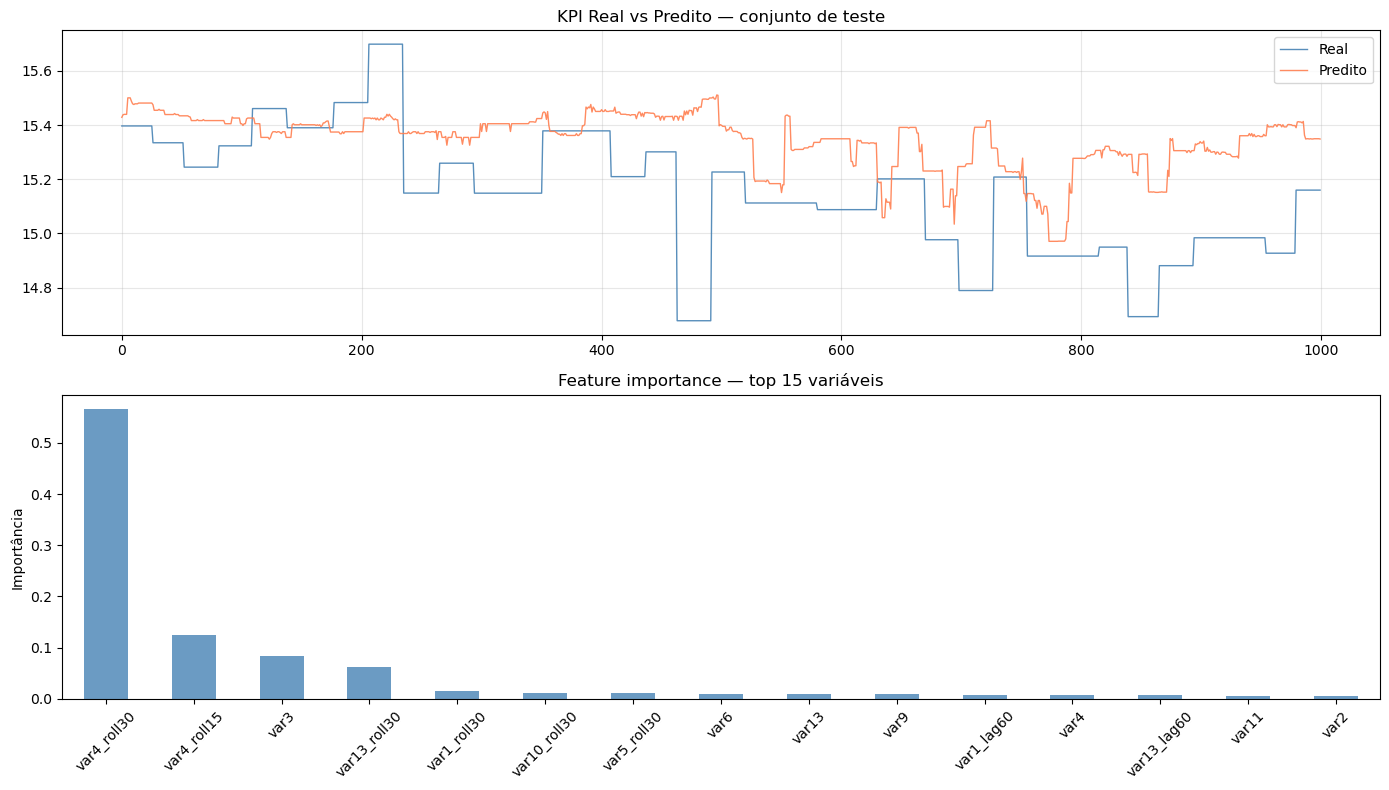

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

n = 1000
axes[0].plot(y2_test.values[:n], label='Real',
             color='steelblue', linewidth=1, alpha=0.9)
axes[0].plot(y2_pred[:n], label='Predito',
             color='coral', linewidth=1, alpha=0.9)
axes[0].set_title('KPI Real vs Predito — conjunto de teste')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importancias = pd.Series(
    modelo_v2.feature_importances_,
    index=features_v2
).sort_values(ascending=False).head(15)

importancias.plot(kind='bar', ax=axes[1],
                  color='steelblue', alpha=0.8)
axes[1].set_title('Feature importance — top 15 variáveis')
axes[1].set_ylabel('Importância')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('resultados.png', dpi=300, bbox_inches='tight')
plt.show()

## Modelagem — 3.6 Interpretação dos resultados

**Gráfico predito vs real:**
O modelo acompanha a tendência geral do KPI mas atenua variações 
abruptas. Comportamento esperado em previsão com 1h de antecedência —
quanto maior o horizonte, mais difícil capturar picos instantâneos.

**Feature importance:**
- `var4_roll30` domina com 57% da importância total
- `var4` aparece 2x no top 3 (roll30 e roll15)
- Médias móveis superam valores instantâneos — confirma que 
  a tendência recente do processo é mais preditiva que o estado atual

**Insight:** var4 é o sensor com maior poder preditivo do KPI.
Monitorar sua tendência de 30 minutos é o principal indicador 
antecedente do desempenho do processo.

**Limitações:**
- R² de 0.40 indica espaço de melhoria
- Modelo suaviza variações bruscas do KPI
- Próximos passos: features de turno, regime operacional separado,
  lags mais longos (120, 180 min)

## Modelagem — 3.7 Autocrítica e conclusões

### O que o modelo faz bem
- Acompanha a tendência geral do KPI ao longo do tempo
- Melhora 22.3% sobre o baseline de prever sempre a média
- Feature engineering com lags aumentou R² em 10.8 pontos percentuais
- var4_roll30 emergiu como principal preditor — insight acionável para 
  o time de operação

### Onde o modelo falha
- R² de 0.40 — explica apenas 40% da variação do KPI
- Atenua variações abruptas — não captura bem saltos rápidos do processo
- Dificuldade em prever eventos de regime diferente (quedas bruscas)

### Por que essas limitações existem
- Horizonte de 1h é longo — quanto maior a antecedência, maior o erro
- Modelo não tem informação de turno ou hora do dia
- Dois regimes operacionais distintos foram tratados juntos

### Próximos passos para melhorar
- Extrair hora e turno do timestamp como features
- Treinar modelos separados por regime operacional
- Testar lags mais longos (120, 180 minutos)
- Avaliar LightGBM e modelos de séries temporais (LSTM)

### Conclusão
O modelo entrega previsão funcional do KPI com 1 hora de antecedência
em resolução de 1 minuto — objetivo central do desafio atingido.
As limitações identificadas são oportunidades claras de melhoria
em iterações futuras.